## FINLORA FINANCE FRAUD DETECTION & SCORING PROJECT ANALYSIS

## Business Prospects — 
Finlora a fintech company that provide transaction monitoring services to clients and merchandise. Due to increase data injection, their fixed monitoring threshold has failed to handle fraud transactions from legitimate transactions. A risk-scoring model built to detect fraud transaction from legitimate payroll, and device priority alerts to flag fraud transaction urgency regardless of actual risk.

## Business Problem — 
Replace rule-based monitoring missing subtle fraud as volume grows with a validated model that catches true fraud transactions.
Translating all information’s into Data driven task— binary classification of transactions as fraudulent vs. legitimate, with a probability score for prioritization.


## Analytical Framework:

| SN | NoteBook Outline |
|---|---|
| **1** | Problem definition document & data source inventory |
| **2** | Clean, analysis-ready dataset (transactions + accounts, joined and feature-engineered) |
| **3** | EDA summary report (fraud vs. legitimate patterns)|
| **4** | Feature importance / behavioral drivers document|
| **5** | Two trained models: Logistic Regression (baseline) + Random Forest (primary)|
| **6** | Model evaluation report (precision, recall, F1, ROC-AUC, confusion matrix, threshold analysis)|
| **7** | Deployed Streamlit dashboard: prioritized, explainable fraud review queue
| **8** | Final documentation + handover summary

## IMPORTING LIBRARIES

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import probplot
import os
import joblib
import plotly.express as px
from datetime import date

## LOAD DATASET

#### Account Dataset:

In [15]:
# 1. Load account CSV file
account_data = pd.read_csv(
    r"C:\Users\User\Documents\10anlyticsDS\Projects\PersonalPJ\AMDARI_PJ\Dataset\Raw_data\finlora_accounts.csv")

# Data Summary
account_summary = pd.DataFrame({
    "Data Type": account_data.dtypes.astype(str),
    "Missing Values": account_data.isna().sum(),
    "% Missing Values": (account_data.isna().mean() * 100).round(2),
    "Unique Values": account_data.nunique(),
    "Duplicate Values": [account_data.duplicated(subset=[col]).sum() for col in account_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

account_summary

,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
account_id,str,0,0.0,7200,0
account_holder_name,str,0,0.0,1000,6200
account_type,str,0,0.0,2,7198
home_country,str,0,0.0,5,7195
currency,str,0,0.0,4,7196
kyc_tier,str,0,0.0,3,7197
account_created_date,str,0,0.0,1443,5757
personal_spend_baseline_usd,float64,0,0.0,6309,891


In [16]:
# View of the Dataset
account_data.head()

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
1,FLR-ACC-100001,Bluewave Foods Ltd,Business,NG,NGN,Tier1_Basic,2026-04-27,810.68
2,FLR-ACC-100002,Global Trading LLC,Business,US,USD,Tier2_Verified,2026-03-29,433.67
3,FLR-ACC-100003,Femi Adeyemi,Individual,NG,NGN,Tier3_Enhanced,2025-09-15,19.18
4,FLR-ACC-100004,Ngozi Brown,Individual,NG,NGN,Tier3_Enhanced,2024-06-18,28.68


In [17]:
# Perform Descriptive analysis of the datset
account_data.describe()

,personal_spend_baseline_usd
count,7200.000000
mean,268.854419
std,495.820753
min,3.770000
25%,43.787500
50%,87.665000
75%,286.807500
max,10469.650000


In [18]:
# Check for Duplicates in account dataset
print("Duplicate rows:",account_data.duplicated().sum())
duplicates = account_data.drop_duplicates().reset_index(drop=True)
print("="*20)

print("Dataset shape after removing duplicates:", duplicates.shape)

Duplicate rows: 0
Dataset shape after removing duplicates: (7200, 8)


In [23]:
# Formating Data type
# 1. convert account_created_date to datetime in pandas
account_data["account_created_date"] = pd.to_datetime(account_data["account_created_date"])

# Converting and extraction day, month, and year
account_data["account_created_year"] = account_data["account_created_date"].dt.year
account_data["account_created_month"] = account_data["account_created_date"].dt.month_name()
account_data["account_created_day"] = account_data["account_created_date"].dt.day_name()
""" So i created a corrected account created date to year, month and day"""


account_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   account_id                   7200 non-null   str           
 1   account_holder_name          7200 non-null   str           
 2   account_type                 7200 non-null   str           
 3   home_country                 7200 non-null   str           
 4   currency                     7200 non-null   str           
 5   kyc_tier                     7200 non-null   str           
 6   account_created_date         7200 non-null   datetime64[us]
 7   personal_spend_baseline_usd  7200 non-null   float64       
 8   account_created_year         7200 non-null   int32         
 9   account_created_month        7200 non-null   str           
 10  account_created_day          7200 non-null   str           
dtypes: datetime64[us](1), float64(1), int32(1), str(8)
mem

In [24]:
account_data.head()

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd,account_created_year,account_created_month,account_created_day
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23,2022,August,Sunday
1,FLR-ACC-100001,Bluewave Foods Ltd,Business,NG,NGN,Tier1_Basic,2026-04-27,810.68,2026,April,Monday
2,FLR-ACC-100002,Global Trading LLC,Business,US,USD,Tier2_Verified,2026-03-29,433.67,2026,March,Sunday
3,FLR-ACC-100003,Femi Adeyemi,Individual,NG,NGN,Tier3_Enhanced,2025-09-15,19.18,2025,September,Monday
4,FLR-ACC-100004,Ngozi Brown,Individual,NG,NGN,Tier3_Enhanced,2024-06-18,28.68,2024,June,Tuesday


In [28]:
print(account_data["currency"].unique())
print(account_data["home_country"].unique())

<ArrowStringArray>
['NGN', 'USD', 'EUR', 'GBP']
Length: 4, dtype: str


<ArrowStringArray>
['NG', 'US', 'FR', 'GB', 'DE']
Length: 5, dtype: str

#### **Transaction Dataset**

In [88]:
# 2. Load transaction CSV file
transaction_data = pd.read_csv(
    r"C:\Users\User\Documents\10anlyticsDS\Projects\PersonalPJ\AMDARI_PJ\Dataset\Raw_data\finlora_transactions.csv")

# Data Summary
transaction_summary = pd.DataFrame({
    "Data Type": transaction_data.dtypes.astype(str),
    "Missing Values": transaction_data.isna().sum(),
    "% Missing Values": (transaction_data.isna().mean() * 100).round(2),
    "Unique Values": transaction_data.nunique(),
    "Duplicate Values": [transaction_data.duplicated(subset=[col]).sum() for col in transaction_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

transaction_summary

,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
merchant_name,str,28610,22.71,63,125936
is_new_device,float64,14334,11.38,2,125997
device_id,str,14334,11.38,14931,111068
transaction_id,str,0,0.00,126000,0
amount_to_avg_ratio,float64,0,0.00,5205,120795
status,str,0,0.00,3,125997
account_age_days,int64,0,0.00,1540,124460
is_cross_border,int64,0,0.00,2,125998
home_country,str,0,0.00,5,125995
transaction_country,str,0,0.00,5,125995


In [89]:
# View of the Dataset
account_data.head()

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd,account_created_year,account_created_month,account_created_day
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23,2022,August,Sunday
1,FLR-ACC-100001,Bluewave Foods Ltd,Business,NG,NGN,Tier1_Basic,2026-04-27,810.68,2026,April,Monday
2,FLR-ACC-100002,Global Trading LLC,Business,US,USD,Tier2_Verified,2026-03-29,433.67,2026,March,Sunday
3,FLR-ACC-100003,Femi Adeyemi,Individual,NG,NGN,Tier3_Enhanced,2025-09-15,19.18,2025,September,Monday
4,FLR-ACC-100004,Ngozi Brown,Individual,NG,NGN,Tier3_Enhanced,2024-06-18,28.68,2024,June,Tuesday


In [90]:
# Performing Descriptive Analysis on transaction dataset
# Numerical summary
numerical_summary = transaction_data.select_dtypes(
    include="number"
).describe().T

# Categorical summary
categorical_summary = transaction_data.select_dtypes(
    include=["object", "category"]
).describe().T

print("NUMERICAL VARIABLES")
display(numerical_summary)

print("\nCATEGORICAL VARIABLES")
display(categorical_summary)

C:\Users\User\AppData\Local\Temp\ipykernel_13016\2395683197.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_summary = transaction_data.select_dtypes(


NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
hour_of_day,126000.0,13.542111,5.260369e+00,0.00,9.0000,14.00,18.0000,2.300000e+01
amount,126000.0,796491.817660,4.054387e+06,-1834602.45,63.1050,5942.24,120847.0375,2.691614e+08
amount_to_avg_ratio,126000.0,7.921400,1.535667e+02,0.00,0.2500,0.98,1.8300,3.176269e+04
avg_transaction_amount_30d,126000.0,767599.456062,3.290377e+06,-1669153.21,92.4275,5942.24,157570.0975,1.733621e+08
transaction_velocity_1h,126000.0,0.011429,1.103226e-01,0.00,0.0000,0.00,0.0000,3.000000e+00
is_cross_border,126000.0,0.020198,1.406790e-01,0.00,0.0000,0.00,0.0000,1.000000e+00
is_new_device,111666.0,0.034881,1.834787e-01,0.00,0.0000,0.00,0.0000,1.000000e+00
account_age_days,126000.0,354.721992,3.313270e+02,0.00,35.0000,289.00,577.0000,1.682000e+03
is_fraud,126000.0,0.026603,1.609213e-01,0.00,0.0000,0.00,0.0000,1.000000e+00



CATEGORICAL VARIABLES


,count,unique,top,freq
transaction_id,126000,126000,FLR250216186265,1
account_id,126000,7144,FLR-ACC-101374,1497
account_type,126000,2,Individual,82112
kyc_tier,126000,3,Tier2_Verified,64094
timestamp,126000,125758,2025-06-27 20:56:40,3
day_of_week,126000,7,Sunday,18402
description,126000,8644,ATM WITHDRAWAL - CHASE ATM,1055
merchant_name,97390,63,International Wire,7584
merchant_category,126000,15,Payroll Transfer,17117
channel,126000,6,Mobile App,41615


##### **Handling Missing Transaction Values

Missing values BEFORE treatment:
--------------------------------------------------
               Missing Data  Missing Percentage
merchant_name         28610               22.71
device_id             14334               11.38
is_new_device         14334               11.38

Visaulization of Missing values BEFORE treatment:
--------------------------------------------------


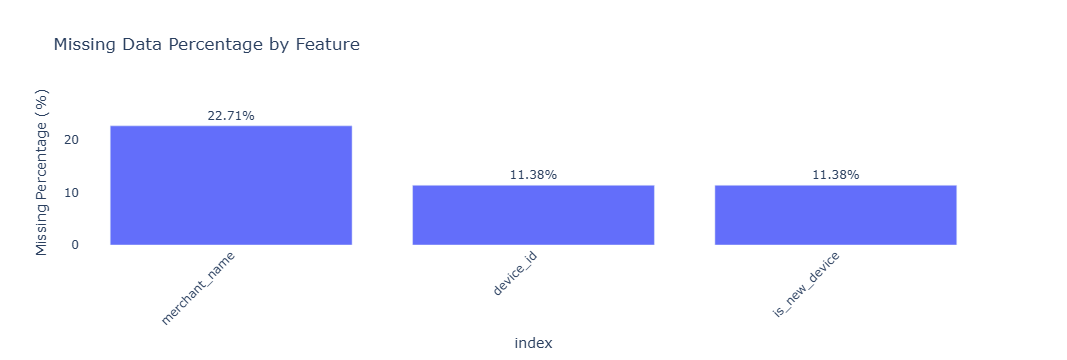

In [91]:
# ----------------------------------------------------------
# 1. Check missing values before treatment
# ----------------------------------------------------------
'''
Create a dataframe to show total number of missing values
and percentage of missing values in transaction data
'''

missing_data = pd.DataFrame({"Missing Data": transaction_data.isnull().sum(), "Missing Percentage": (transaction_data.isnull().mean() * 100).round(2)})

# Show only columns that contain missing values
missing_data = (missing_data[missing_data["Missing Data"] > 0].sort_values("Missing Percentage", ascending=False))

print("Missing values BEFORE treatment:")
print("--"*25)
print(missing_data)
print()


# Visualizing the Missing Data
print("Visaulization of Missing values BEFORE treatment:")
print("--"*25)
fig = px.bar(missing_data, x=missing_data.index, y="Missing Percentage",
             title="Missing Data Percentage by Feature",
             labels={"x": "Features", "Missing Percentage": "Missing Percentage (%)"},
             text="Missing Percentage")

fig.update_traces( texttemplate="%{text:.2f}%", textposition="outside")

fig.update_layout(showlegend=False, plot_bgcolor="white", paper_bgcolor="white",
                  xaxis=dict(showgrid=False, tickangle=-45), yaxis=dict(showgrid=False))

fig.show()

In [92]:
# ----------------------------------------------------------------
# 2. Identify numerical columns with missing data
# ----------------------------------------------------------------
'''
Since this missing values are tracnsaction amount, its is best to use median
'''
numerical_columns = transaction_data.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical columns with missing values:")
print("=" * 60)



# categorical_columns = merged_data.select_dtypes(include=["object", "category"]).columns.tolist()


# ----------------------------------------------------------
# 3. Fill numerical missing values with median
# ----------------------------------------------------------
for column in numerical_columns:
    missing_count = transaction_data[column].isnull().sum()
    if missing_count > 0:
        print(f"\nColumn: {column}")
        print(f"Missing values: {missing_count}")

        # Calculate median
        median_value = transaction_data[column].median()
        print(f"Median value: {median_value}")

        # Fill missing values with median
        transaction_data[column] = transaction_data[column].fillna(median_value)
        print(f"Missing values handled using median.")

Numerical columns with missing values:

Column: is_new_device
Missing values: 14334
Median value: 0.0
Missing values handled using median.


In [93]:
# ----------------------------------------------------------------
# 3. Identify categorical columns with missing data
# ----------------------------------------------------------------
'''
its important to note that not in all cases of categorical column that need mode. 
for the merchant name its best to use unknown merchant for better encoding process.
same for device Id too.
'''
custom_values = {"device_id": "Unknown_ID", "merchant_name": "Unknown_Merchant"}

for column, value in custom_values.items():
    if column in transaction_data.columns:
        missing_before = transaction_data[column].isnull().sum()

        if missing_before > 0:
            transaction_data[column] = (transaction_data[column].fillna(value))

            missing_after = transaction_data[column].isnull().sum()
            print(f"\nColumn: {column}")
            print(f"Missing before: {missing_before}")
            print(f"Custom value: {value}")
            print(f"Missing after: {missing_after}")   


Column: device_id
Missing before: 14334
Custom value: Unknown_ID
Missing after: 0

Column: merchant_name
Missing before: 28610
Custom value: Unknown_Merchant
Missing after: 0


#### Check for Duplicate transaction data

In [94]:
print("Duplicate rows:",transaction_data.duplicated().sum())
duplicates = transaction_data.drop_duplicates().reset_index(drop=True)
print("="*20)

print("Dataset shape after removing duplicates:", duplicates.shape)

Duplicate rows: 0
Dataset shape after removing duplicates: (126000, 24)


#### Currency Normalization to currency of reference (USD)

In [95]:
# FX exchange rates to USD, September 2026

EXCHANGE_RATE = {
    "USD": 1.000,          # USD → USD
    "GBP": 1.339, # GBP → USD
    "EUR": 1.1582,     # EUR → USD
    "NGN": 0.001       # NGN → USD (approximate)
}

# Convert transaction amount to USD
transaction_data["amount_usd"] = (
    transaction_data["amount"] *
    transaction_data["currency"].map(EXCHANGE_RATE)
)

# Median transaction value in USD by currency
currencies = (
    transaction_data
    .groupby("currency")["amount_usd"]
    .median()
    .round(2)
    .sort_values(ascending=False)
)

print(currencies)

currency
NGN    114.69
GBP     74.92
EUR     66.93
USD     66.57
Name: amount_usd, dtype: float64


##### Handling the Negative Numerical transaction data 

In [96]:
##### Handling the Negative Numerical transaction data (amount & avg_transaction_amount_30d)
amount_columns = ["amount", "avg_transaction_amount_30d"]
for column in amount_columns:

    # Create binary indicator for negative values
    indicator_column = f"{column}_is_negative"
    transaction_data[indicator_column] = (transaction_data[column] < 0).astype(int)

    # Create absolute-value version
    absolute_column = f"{column}_absolute"
    transaction_data[absolute_column] = (transaction_data[column].abs())

print(transaction_data[
    ["amount",
     "amount_is_negative",
     "amount_absolute",
     "avg_transaction_amount_30d",
     "avg_transaction_amount_30d_is_negative",
     "avg_transaction_amount_30d_absolute"]].head(10))

      amount  amount_is_negative  amount_absolute  avg_transaction_amount_30d  \
0   84233.00                   0         84233.00                     9143.33   
1    9143.33                   0          9143.33                     9143.33   
2   20639.00                   0         20639.00                     9143.33   
3    3177.43                   0          3177.43                    14891.16   
4   97839.52                   0         97839.52                    49609.59   
5   49609.59                   0         49609.59                    49609.59   
6  206814.22                   0        206814.22                    49609.59   
7    6010.89                   0          6010.89                   206814.22   
8   31458.32                   0         31458.32                    31458.32   
9    6525.42                   0          6525.42                    31458.32   

   avg_transaction_amount_30d_is_negative  avg_transaction_amount_30d_absolute  
0                          

##### Formating Timestamp type

In [97]:
# Convert timestamp to datetime
transaction_data["timestamp"] = pd.to_datetime(transaction_data["timestamp"], errors="coerce")

# Check the data type
print(transaction_data["timestamp"].dtype)
# Converting and extraction day, month, and year
transaction_data["transaction_year"] = transaction_data["timestamp"].dt.year
transaction_data["transaction_month"] = transaction_data["timestamp"].dt.month_name()
transaction_data["transaction_day"] = transaction_data["timestamp"].dt.day_name()
transaction_data["transaction_hour"] = (transaction_data["timestamp"].dt.hour)
transaction_data["is_weekend"] = (transaction_data["timestamp"].dt.dayofweek >= 5).astype(int)
""" So i created a corrected account created date to year, month and day"""

transaction_data.info()

datetime64[us]
<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 34 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   transaction_id                          126000 non-null  str           
 1   account_id                              126000 non-null  str           
 2   account_type                            126000 non-null  str           
 3   kyc_tier                                126000 non-null  str           
 4   timestamp                               126000 non-null  datetime64[us]
 5   day_of_week                             126000 non-null  str           
 6   hour_of_day                             126000 non-null  int64         
 7   description                             126000 non-null  str           
 8   merchant_name                           126000 non-null  str           
 9   merchant_category                

In [98]:
transaction_data.head()

,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,...,amount_usd,amount_is_negative,amount_absolute,avg_transaction_amount_30d_is_negative,avg_transaction_amount_30d_absolute,transaction_year,transaction_month,transaction_day,transaction_hour,is_weekend
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,...,84.23300,0,84233.00,0,9143.33,2025,February,Sunday,14,1
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,...,9.14333,0,9143.33,0,9143.33,2025,April,Wednesday,13,0
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,...,20.63900,0,20639.00,0,9143.33,2025,April,Thursday,12,0
3,FLR250428101772,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,Subscription/SaaS,...,3.17743,0,3177.43,0,14891.16,2025,April,Monday,14,0
4,FLR250628102827,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,Electronics,...,97.83952,0,97839.52,0,49609.59,2025,June,Saturday,16,1


### Concatenate Both Dataset & Save to Cleaned Data:

In [99]:
# 1. Merging the two datasets
# Remove duplicate account-level columns from Dataset 2
transaction_data = transaction_data.drop(
    columns=["account_type", "kyc_tier", "currency", "home_country"])

# Merge datasets
merged_data = pd.merge(account_data, transaction_data, on="account_id", how="inner")

# Display columns
print("Merged Dataset Columns:")
print(merged_data.columns.tolist())

# Merged Data Summary
merged_summary = pd.DataFrame({
    "Data Type": merged_data.dtypes.astype(str),
    "Missing Values": merged_data.isna().sum(),
    "% Missing Values": (merged_data.isna().mean() * 100).round(2),
    "Unique Values": merged_data.nunique(),
    "Duplicate Values": [merged_data.duplicated(subset=[col]).sum() for col in merged_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

Merged Dataset Columns:
['account_id', 'account_holder_name', 'account_type', 'home_country', 'currency', 'kyc_tier', 'account_created_date', 'personal_spend_baseline_usd', 'account_created_year', 'account_created_month', 'account_created_day', 'transaction_id', 'timestamp', 'day_of_week', 'hour_of_day', 'description', 'merchant_name', 'merchant_category', 'channel', 'amount', 'amount_to_avg_ratio', 'avg_transaction_amount_30d', 'transaction_velocity_1h', 'transaction_country', 'is_cross_border', 'device_id', 'is_new_device', 'account_age_days', 'status', 'is_fraud', 'amount_usd', 'amount_is_negative', 'amount_absolute', 'avg_transaction_amount_30d_is_negative', 'avg_transaction_amount_30d_absolute', 'transaction_year', 'transaction_month', 'transaction_day', 'transaction_hour', 'is_weekend']


In [100]:
# 2. Save the merged dataset as a new CSV file
output_folder = r"C:\Users\User\Documents\10anlyticsDS\Projects\PersonalPJ\AMDARI_PJ\Dataset\preprocessed_data"

os.makedirs(output_folder, exist_ok=True)

# Save the merged dataset
output_file = os.path.join(output_folder, "Cleaned_Finlora_Data.csv")

merged_data.to_csv(output_file, index=False)

# 5. Confirm the result
print("Cleaned dataset created successfully!")
print("Rows and columns:", merged_data.shape)
print("File saved as: Cleaned_Finlora_Data.csv")

Cleaned dataset created successfully!
Rows and columns: (126000, 40)
File saved as: Cleaned_Finlora_Data.csv


In [101]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   account_id                              126000 non-null  str           
 1   account_holder_name                     126000 non-null  str           
 2   account_type                            126000 non-null  str           
 3   home_country                            126000 non-null  str           
 4   currency                                126000 non-null  str           
 5   kyc_tier                                126000 non-null  str           
 6   account_created_date                    126000 non-null  datetime64[us]
 7   personal_spend_baseline_usd             126000 non-null  float64       
 8   account_created_year                    126000 non-null  int32         
 9   account_created_month                   126000 n